# Análisis de Reflectancia en Películas Delgadas de Aluminio

## Espectrometría de Reflectancia a Múltiples Ángulos (30°, 45°, 60°)

En este notebook se analiza la reflectancia relativa de una película delgada de aluminio medida a diferentes ángulos de incidencia utilizando un espectrómetro Thorlabs CCS-100.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración de matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Paso 1: Cargar Datos Experimentales

Los datos se obtuvieron del espectrómetro Thorlabs CCS-100 con las siguientes mediciones:
- **r (Reference)**: Espectro del estándar especular (referencia)
- **dr (Dark Reference)**: Espectro oscuro de la referencia
- **Rmuestra (Sample)**: Espectro de la película delgada de aluminio
- **Dsample (Dark Sample)**: Espectro oscuro de la muestra

In [3]:
# Función para cargar archivos CSV del espectrómetro Thorlabs
def load_thorlabs_csv(filepath):
    """
    Carga un archivo CSV del espectrómetro Thorlabs,
    extrayendo los datos después de la sección [Data]
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Encontrar la línea [Data]
    data_start = None
    data_end = None
    for i, line in enumerate(lines):
        if '[Data]' in line:
            data_start = i + 1
        elif '[EndOfFile]' in line:
            data_end = i
            break

    if data_start is None:
        raise ValueError("No se encontró la sección [Data] en el archivo")

    # Leer solo las líneas de datos
    if data_end is None:
        data_lines = lines[data_start:]
    else:
        data_lines = lines[data_start:data_end]

    # Crear un string con los datos y leerlo con pandas
    from io import StringIO
    data_str = ''.join(data_lines)

    df = pd.read_csv(StringIO(data_str), sep=';', header=None,
                     names=['Wavelength (nm)', 'Intensity'],
                     dtype={'Wavelength (nm)': float, 'Intensity': float})

    return df

# Definir rutas y ángulos
data_dir = Path('/home/juan/Workspace/Base/Python/Lab2/thin_films')
angles = [30, 45, 60]

# Cargar todos los datos
spectra = {}

for angle in angles:
    spectra[angle] = {
        'r': load_thorlabs_csv(data_dir / f'r{angle}.csv'),
        'dr': load_thorlabs_csv(data_dir / f'dr{angle}.csv'),
        'sample': load_thorlabs_csv(data_dir / f'Rmuestra-{angle}G-G2.csv'),
        'dsample': load_thorlabs_csv(data_dir / f'Dsample-{angle}G-G2.csv')
    }

# Mostrar información de los datos cargados
print("Datos cargados exitosamente para los ángulos:", angles)
for angle in angles:
    print(f"\nÁngulo {angle}°:")
    for key in spectra[angle]:
        print(f"  {key}: {len(spectra[angle][key])} puntos de medición")

Datos cargados exitosamente para los ángulos: [30, 45, 60]

Ángulo 30°:
  r: 3648 puntos de medición
  dr: 3648 puntos de medición
  sample: 3648 puntos de medición
  dsample: 3648 puntos de medición

Ángulo 45°:
  r: 3648 puntos de medición
  dr: 3648 puntos de medición
  sample: 3648 puntos de medición
  dsample: 3648 puntos de medición

Ángulo 60°:
  r: 3648 puntos de medición
  dr: 3648 puntos de medición
  sample: 3648 puntos de medición
  dsample: 3648 puntos de medición


## Paso 2: Calcular Reflectancia Relativa

La reflectancia relativa se calcula usando la fórmula:

$$R(\lambda) = \frac{S(\lambda) - D_s(\lambda)}{R(\lambda) - D_r(\lambda)}$$

Donde:
- $S(\lambda)$: Intensidad del espectro de la muestra
- $D_s(\lambda)$: Intensidad del espectro oscuro de la muestra
- $R(\lambda)$: Intensidad del espectro de referencia
- $D_r(\lambda)$: Intensidad del espectro oscuro de la referencia

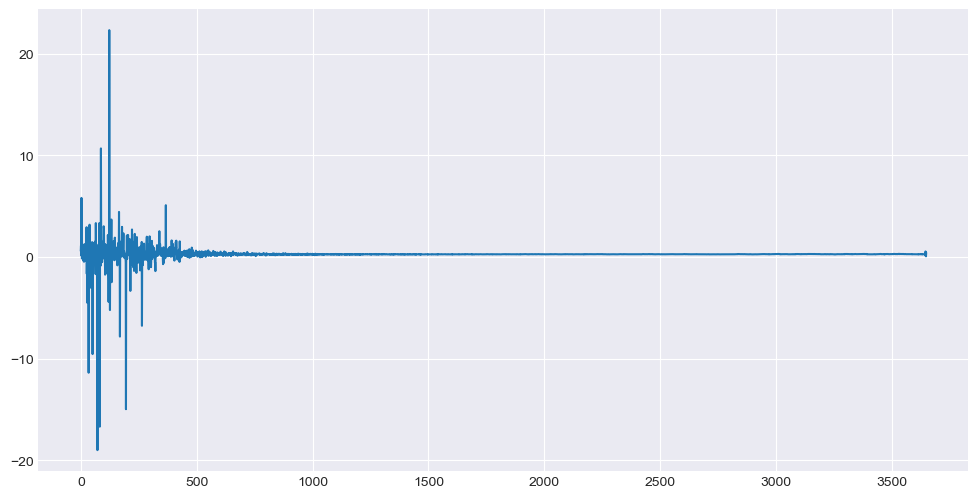

In [4]:
df_Dr = load_thorlabs_csv("thin_films/dr30.csv")
df_F = load_thorlabs_csv("thin_films/r30.csv")
df_Ds = load_thorlabs_csv("thin_films/Dsample-30G-G2.csv")
df_S = load_thorlabs_csv("thin_films/Rmuestra-30G-G2.csv")
plt.plot((df_S['Intensity'] - df_Ds['Intensity'])/(df_F['Intensity'] - df_Dr['Intensity']))
plt.show()

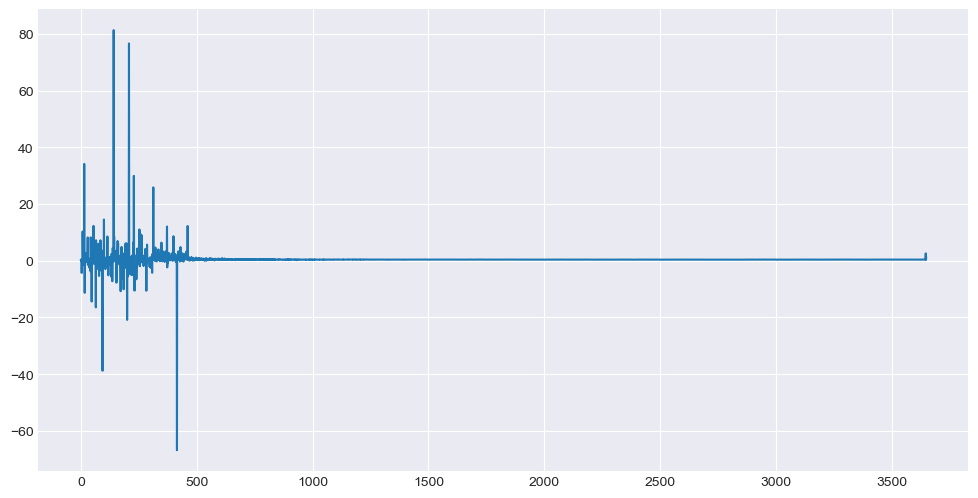

In [5]:
df_Dr = load_thorlabs_csv("thin_films/dr45.csv")
df_F = load_thorlabs_csv("thin_films/r45.csv")
df_Ds = load_thorlabs_csv("thin_films/Dsample-45G-G2.csv")
df_S = load_thorlabs_csv("thin_films/Rmuestra-45G-G2.csv")
plt.plot((df_S['Intensity'] - df_Ds['Intensity'])/(df_F['Intensity'] - df_Dr['Intensity']))
plt.show()

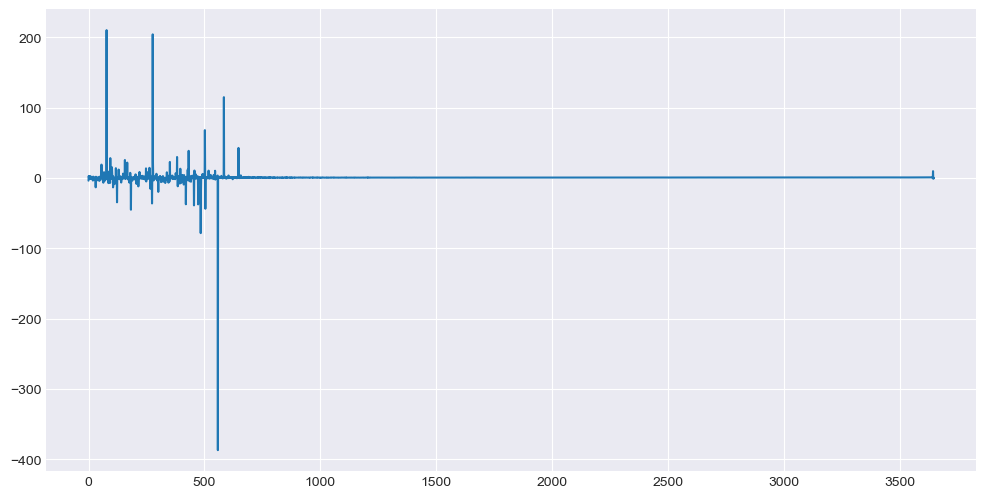

In [6]:
df_Dr = load_thorlabs_csv("thin_films/dr60.csv")
df_F = load_thorlabs_csv("thin_films/r60.csv")
df_Ds = load_thorlabs_csv("thin_films/Dsample-60G-G2.csv")
df_S = load_thorlabs_csv("thin_films/Rmuestra-60G-G2.csv")
plt.plot((df_S['Intensity'] - df_Ds['Intensity'])/(df_F['Intensity'] - df_Dr['Intensity']))
plt.show()

In [7]:
# Calcular reflectancia relativa para cada ángulo
reflectance = {}

for angle in angles:
    # Obtener datos
    S = spectra[angle]['sample']['Intensity'].values
    Ds = spectra[angle]['dsample']['Intensity'].values
    R = spectra[angle]['r']['Intensity'].values
    Dr = spectra[angle]['dr']['Intensity'].values
    wavelength = spectra[angle]['sample']['Wavelength (nm)'].values

    # Calcular reflectancia relativa: (S - Ds) / (R - Dr)
    R_rel = (S - Ds) / (R - Dr)

    # Guardar resultados
    reflectance[angle] = pd.DataFrame({
        'Wavelength (nm)': wavelength,
        'Reflectance': R_rel
    })

    print(f"\nÁngulo {angle}°:")
    print(f"  Reflectancia relativa - Mín: {R_rel.min():.4f}, Máx: {R_rel.max():.4f}")
    print(f"  Media: {R_rel.mean():.4f}")


Ángulo 30°:
  Reflectancia relativa - Mín: -19.0030, Máx: 22.3235
  Media: 0.2789

Ángulo 45°:
  Reflectancia relativa - Mín: -66.7761, Máx: 81.3027
  Media: 0.4708

Ángulo 60°:
  Reflectancia relativa - Mín: -387.1383, Máx: 210.1341
  Media: 0.4789


## Paso 3: Visualizar Reflectancia Relativa

Gráficas de la reflectancia relativa medida a los tres ángulos de incidencia.

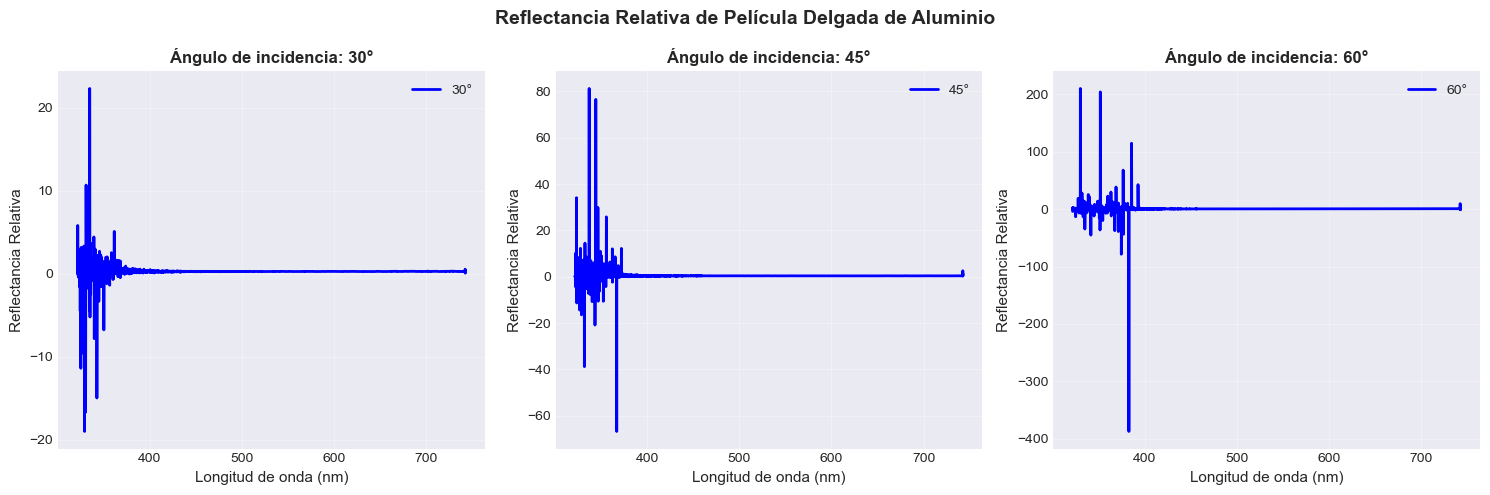

In [8]:
# Gráfica individual para cada ángulo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Reflectancia Relativa de Película Delgada de Aluminio', fontsize=14, fontweight='bold')

for idx, angle in enumerate(angles):
    ax = axes[idx]
    wavelength = reflectance[angle]['Wavelength (nm)'].values
    R_rel = reflectance[angle]['Reflectance'].values

    ax.plot(wavelength, R_rel, 'b-', linewidth=2, label=f'{angle}°')
    ax.set_xlabel('Longitud de onda (nm)', fontsize=11)
    ax.set_ylabel('Reflectancia Relativa', fontsize=11)
    ax.set_title(f'Ángulo de incidencia: {angle}°', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Paso 4: Comparativa de Reflectancia a Diferentes Ángulos

Gráfica superpuesta de los tres ángulos para analizar cómo varía la reflectancia con el ángulo de incidencia.

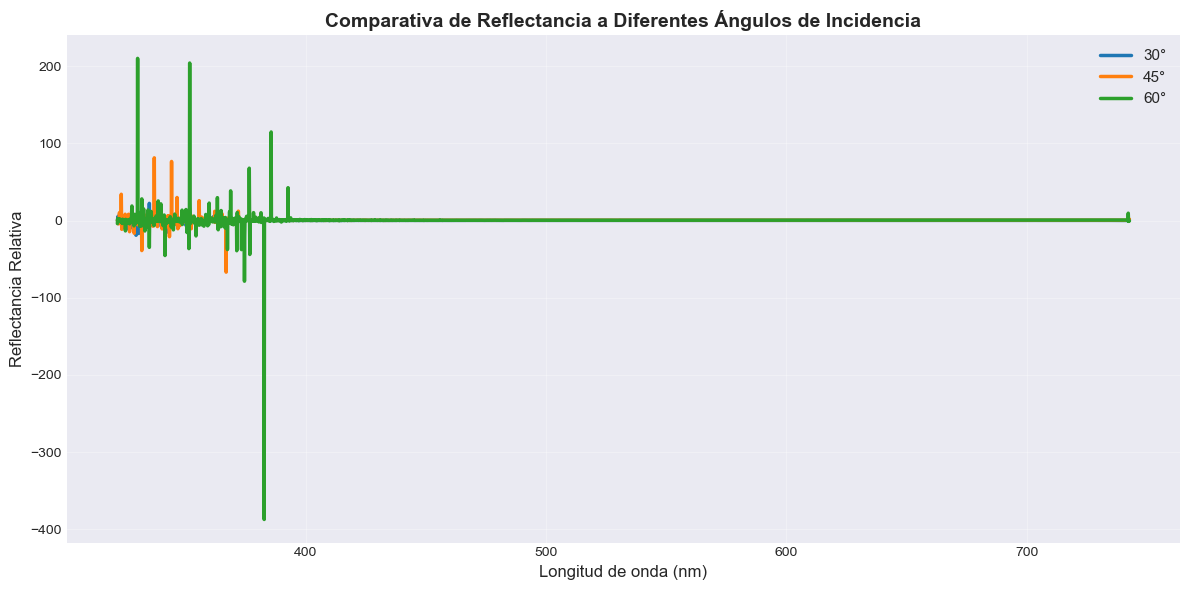

In [9]:
# Gráfica superpuesta de los tres ángulos
plt.figure(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, angle in enumerate(angles):
    wavelength = reflectance[angle]['Wavelength (nm)'].values
    R_rel = reflectance[angle]['Reflectance'].values
    plt.plot(wavelength, R_rel, linewidth=2.5, label=f'{angle}°', color=colors[idx])

plt.xlabel('Longitud de onda (nm)', fontsize=12)
plt.ylabel('Reflectancia Relativa', fontsize=12)
plt.title('Comparativa de Reflectancia a Diferentes Ángulos de Incidencia', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 5: Análisis Estadístico de Reflectancia

Estadísticas descriptivas de la reflectancia relativa en función del ángulo de incidencia.

In [10]:
# Crear tabla de estadísticas
stats_data = []

for angle in angles:
    R_rel = reflectance[angle]['Reflectance'].values
    stats_data.append({
        'Ángulo (°)': angle,
        'Mínimo': R_rel.min(),
        'Máximo': R_rel.max(),
        'Media': R_rel.mean(),
        'Desv. Est.': R_rel.std(),
        'Mediana': np.median(R_rel)
    })

stats_df = pd.DataFrame(stats_data)
print("\nEstadísticas de Reflectancia Relativa por Ángulo:")
print(stats_df.to_string(index=False))


Estadísticas de Reflectancia Relativa por Ángulo:
 Ángulo (°)      Mínimo     Máximo    Media  Desv. Est.  Mediana
         30  -19.003027  22.323527 0.278917    0.793476 0.273884
         45  -66.776067  81.302728 0.470821    2.653014 0.401081
         60 -387.138258 210.134106 0.478853    8.828924 0.512780


## Paso 6: Análisis de Comportamiento Espectral

Estudio detallado de cómo varía la reflectancia en diferentes regiones espectrales.

In [11]:
# Análisis de regiones espectrales
# Dividir en regiones: UV (300-400), Visible (400-700), IR cercano (700-1000)

regions = {
    'UV': (300, 400),
    'Visible': (400, 700),
    'IR Cercano': (700, 1000)
}

print("\n" + "="*70)
print("ANÁLISIS POR REGIÓN ESPECTRAL")
print("="*70)

for angle in angles:
    print(f"\n{'Ángulo: '+str(angle)+'°':^70}")
    print("-"*70)

    wavelength = reflectance[angle]['Wavelength (nm)'].values
    R_rel = reflectance[angle]['Reflectance'].values

    for region_name, (wmin, wmax) in regions.items():
        mask = (wavelength >= wmin) & (wavelength < wmax)
        if mask.any():
            R_region = R_rel[mask]
            print(f"  {region_name:12} ({wmin:3d}-{wmax:3d} nm): "
                  f"Media = {R_region.mean():.4f}, Std = {R_region.std():.4f}")
        else:
            print(f"  {region_name:12}: No hay datos en este rango")


ANÁLISIS POR REGIÓN ESPECTRAL

                             Ángulo: 30°                              
----------------------------------------------------------------------
  UV           (300-400 nm): Media = 0.3019, Std = 1.7942
  Visible      (400-700 nm): Media = 0.2718, Std = 0.0176
  IR Cercano   (700-1000 nm): Media = 0.2844, Std = 0.0227

                             Ángulo: 45°                              
----------------------------------------------------------------------
  UV           (300-400 nm): Media = 0.7518, Std = 5.9920
  Visible      (400-700 nm): Media = 0.4006, Std = 0.0226
  IR Cercano   (700-1000 nm): Media = 0.4165, Std = 0.1265

                             Ángulo: 60°                              
----------------------------------------------------------------------
  UV           (300-400 nm): Media = 0.2809, Std = 19.9652
  Visible      (400-700 nm): Media = 0.5071, Std = 0.0956
  IR Cercano   (700-1000 nm): Media = 0.6683, Std = 0.4878


## Paso 7: Variación de la Reflectancia con el Ángulo de Incidencia

Análisis de cómo cambia la reflectancia a una longitud de onda específica cuando varía el ángulo de incidencia.

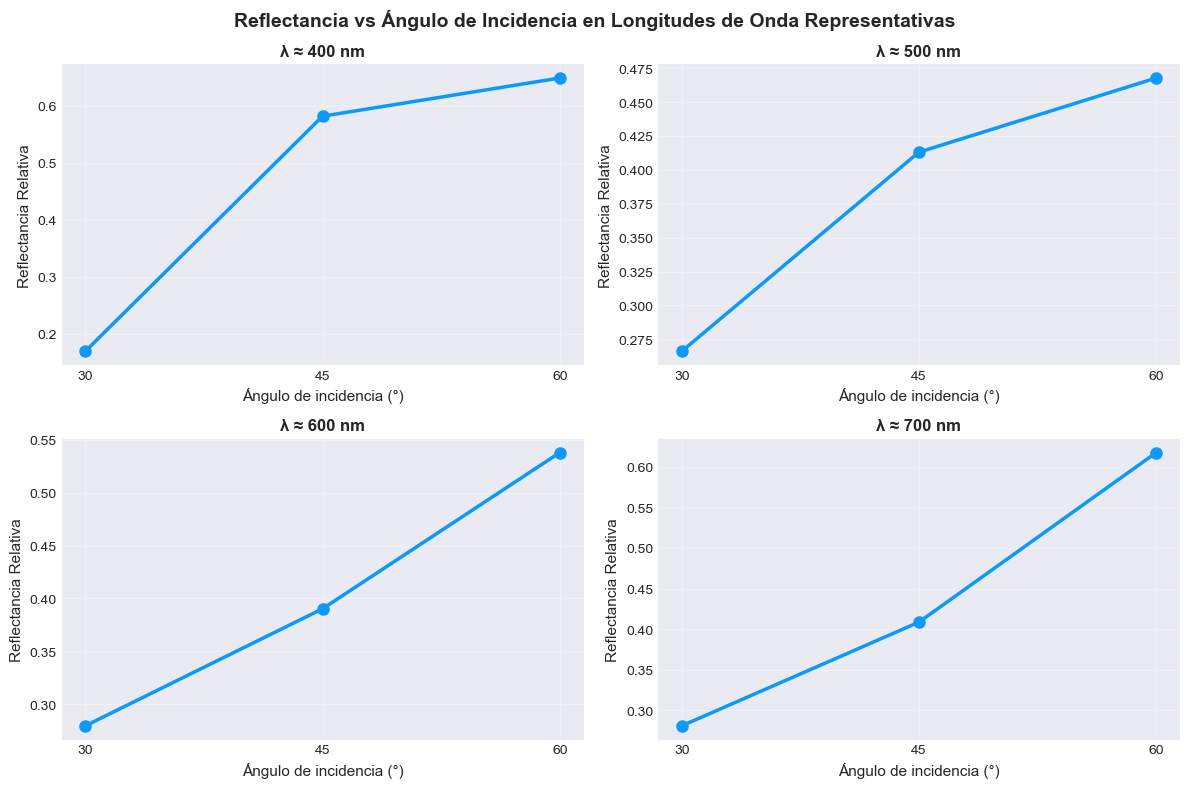

In [12]:
# Seleccionar longitudes de onda representativas para analizar la dependencia angular
representative_wavelengths = [400, 500, 600, 700]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

fig.suptitle('Reflectancia vs Ángulo de Incidencia en Longitudes de Onda Representativas',
             fontsize=14, fontweight='bold')

for idx, wavelength_target in enumerate(representative_wavelengths):
    ax = axes[idx]
    angular_data = []

    for angle in angles:
        # Encontrar el índice de la longitud de onda más cercana
        wl = reflectance[angle]['Wavelength (nm)'].values
        idx_wl = np.argmin(np.abs(wl - wavelength_target))
        R_at_wl = reflectance[angle]['Reflectance'].values[idx_wl]
        angular_data.append(R_at_wl)

    ax.plot(angles, angular_data, 'o-', linewidth=2.5, markersize=8, color="#0999ff")
    ax.set_xlabel('Ángulo de incidencia (°)', fontsize=11)
    ax.set_ylabel('Reflectancia Relativa', fontsize=11)
    ax.set_title(f'λ ≈ {wavelength_target} nm', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(angles)

plt.tight_layout()
plt.show()

## Paso 8: Cálculo de n y k (Índice de Refracción Complejo)

Se realiza un ajuste de mínimos cuadrados para determinar el índice de refracción complejo $N = n + ik$ de la muestra.
Se utiliza el modelo de Fresnel para calcular la reflectancia teórica y se minimiza la diferencia con los datos experimentales en el rango de 440-700 nm.

In [13]:
from scipy.optimize import least_squares

# --- Funciones de Fresnel y Residuos (Basado en CalculateNK.py) ---

def fresnel_RsRp(N, theta_inc_deg):
    """
    Calcula Rs y Rp para un material con índice complejo N = n + 1j*k,
    a un ángulo de incidencia theta_inc_deg (grados) en aire (n0=1).
    """
    theta_inc_rad = np.deg2rad(theta_inc_deg)
    n0 = 1.0
    # Ley de Snell: kz en el medio (complejo)
    sin_t = n0 * np.sin(theta_inc_rad) / N  # complejo
    # argumento de la raíz para cos_t: sqrt(1 - sin^2)
    cos_t = np.sqrt(1.0 - sin_t**2)
    # cos incidencia
    cos_i = np.cos(theta_inc_rad)
    
    # Coeficientes de Fresnel (complejos)
    rs = (n0 * cos_i - N * cos_t) / (n0 * cos_i + N * cos_t)
    rp = (N * cos_i - n0 * cos_t) / (N * cos_i + n0 * cos_t)
    
    Rs = np.abs(rs)**2
    Rp = np.abs(rp)**2
    return Rs.real, Rp.real

def residuals_nk(params, R_meas, angles_deg):
    """
    params = [n, k]
    R_meas: reflectancias medidas (array)
    angles_deg: ángulos en grados (array)
    """
    n, k = params
    # Penalización para valores no físicos
    if n < 0 or k < 0:
        return 1e3 * np.ones_like(R_meas)
        
    N = n + 1j * k
    res = []
    for idx, th in enumerate(angles_deg):
        Rs, Rp = fresnel_RsRp(N, th)
        Rcalc = 0.5 * (Rs + Rp)   # Promedio no polarizado
        res.append(Rcalc - R_meas[idx])
        
    return np.asarray(res)

In [14]:
# --- Preparación de Datos para el Ajuste ---

# Rango de longitud de onda solicitado
wmin_fit, wmax_fit = 440, 700

# Usamos las longitudes de onda de 30 grados como referencia
wl_ref = reflectance[30]['Wavelength (nm)'].values
mask_fit = (wl_ref >= wmin_fit) & (wl_ref <= wmax_fit)
wavelengths_fit = wl_ref[mask_fit]

# Construir matriz de reflectancias experimentales para el rango seleccionado
# Filas: longitudes de onda, Columnas: ángulos [30, 45, 60]
R_exp_matrix = []

for i in range(len(wavelengths_fit)):
    wl = wavelengths_fit[i]
    row = []
    for angle in angles:
        # Buscar el valor de reflectancia para esta longitud de onda en cada ángulo
        # Asumimos que los arrays de longitud de onda son idénticos. 
        # Si no lo fueran, habría que interpolar. Aquí usamos el índice de la máscara.
        # Verificamos consistencia:
        r_data = reflectance[angle]
        val = r_data.loc[mask_fit, 'Reflectance'].values[i]
        row.append(val)
    R_exp_matrix.append(row)

R_exp_matrix = np.array(R_exp_matrix)
print(f"Datos preparados para ajuste: {len(wavelengths_fit)} puntos de longitud de onda entre {wmin_fit} y {wmax_fit} nm.")

Datos preparados para ajuste: 2220 puntos de longitud de onda entre 440 y 700 nm.


In [15]:
# --- Bucle de Ajuste ---

n_fit = []
k_fit = []
cost_fit = []

# Valores iniciales propuestos
x0 = [1.0, 5.0] 
bounds = ([0, 0], [np.inf, np.inf])
angles_list = [30, 45, 60]

print("Iniciando ajuste de n y k...")

for i in range(len(wavelengths_fit)):
    R_vals = R_exp_matrix[i]
    
    try:
        res = least_squares(residuals_nk, x0, args=(R_vals, angles_list), 
                            bounds=bounds, ftol=1e-10, xtol=1e-10, gtol=1e-10)
        n_fit.append(res.x[0])
        k_fit.append(res.x[1])
        cost_fit.append(res.cost)
        
        # Opcional: usar el resultado anterior como semilla para el siguiente (continuidad)
        # x0 = res.x 
    except Exception as e:
        print(f"Error en ajuste a {wavelengths_fit[i]} nm: {e}")
        n_fit.append(np.nan)
        k_fit.append(np.nan)
        cost_fit.append(np.nan)

print("Ajuste finalizado.")

# Crear DataFrame con resultados
nk_results = pd.DataFrame({
    'Wavelength (nm)': wavelengths_fit,
    'n': n_fit,
    'k': k_fit,
    'Cost': cost_fit
})

Iniciando ajuste de n y k...
Ajuste finalizado.
Ajuste finalizado.


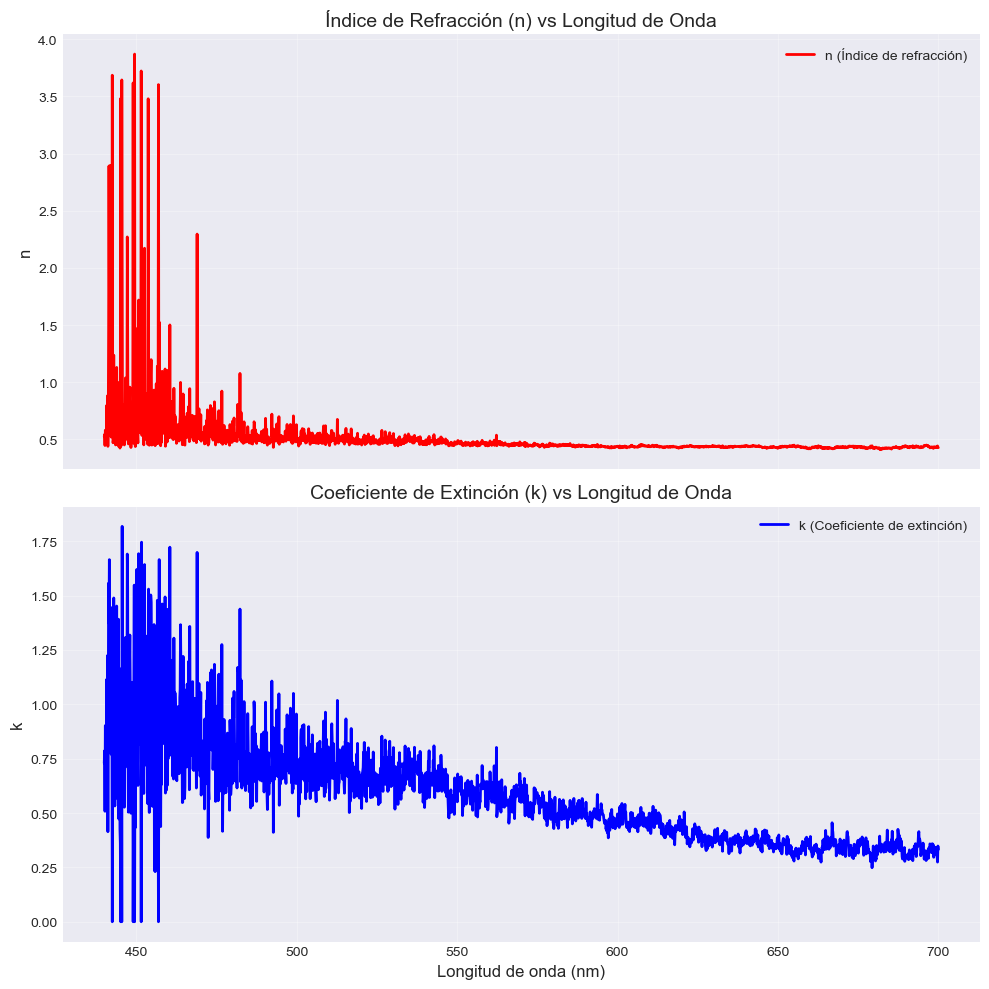

Resultados guardados en: /home/juan/Workspace/Base/Python/imagenes/nk_results.csv


In [16]:
# --- Visualización de Resultados ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Gráfica de n
ax1.plot(nk_results['Wavelength (nm)'], nk_results['n'], 'r-', linewidth=2, label='n (Índice de refracción)')
ax1.set_ylabel('n', fontsize=12)
ax1.set_title('Índice de Refracción (n) vs Longitud de Onda', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfica de k
ax2.plot(nk_results['Wavelength (nm)'], nk_results['k'], 'b-', linewidth=2, label='k (Coeficiente de extinción)')
ax2.set_xlabel('Longitud de onda (nm)', fontsize=12)
ax2.set_ylabel('k', fontsize=12)
ax2.set_title('Coeficiente de Extinción (k) vs Longitud de Onda', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Guardar resultados
output_path = data_dir.parent.parent / 'imagenes' / 'nk_results.csv'
# Asegurar que el directorio existe (aunque 'imagenes' ya existe en el workspace info)
output_path.parent.mkdir(parents=True, exist_ok=True)
nk_results.to_csv(output_path, index=False)
print(f"Resultados guardados en: {output_path}")

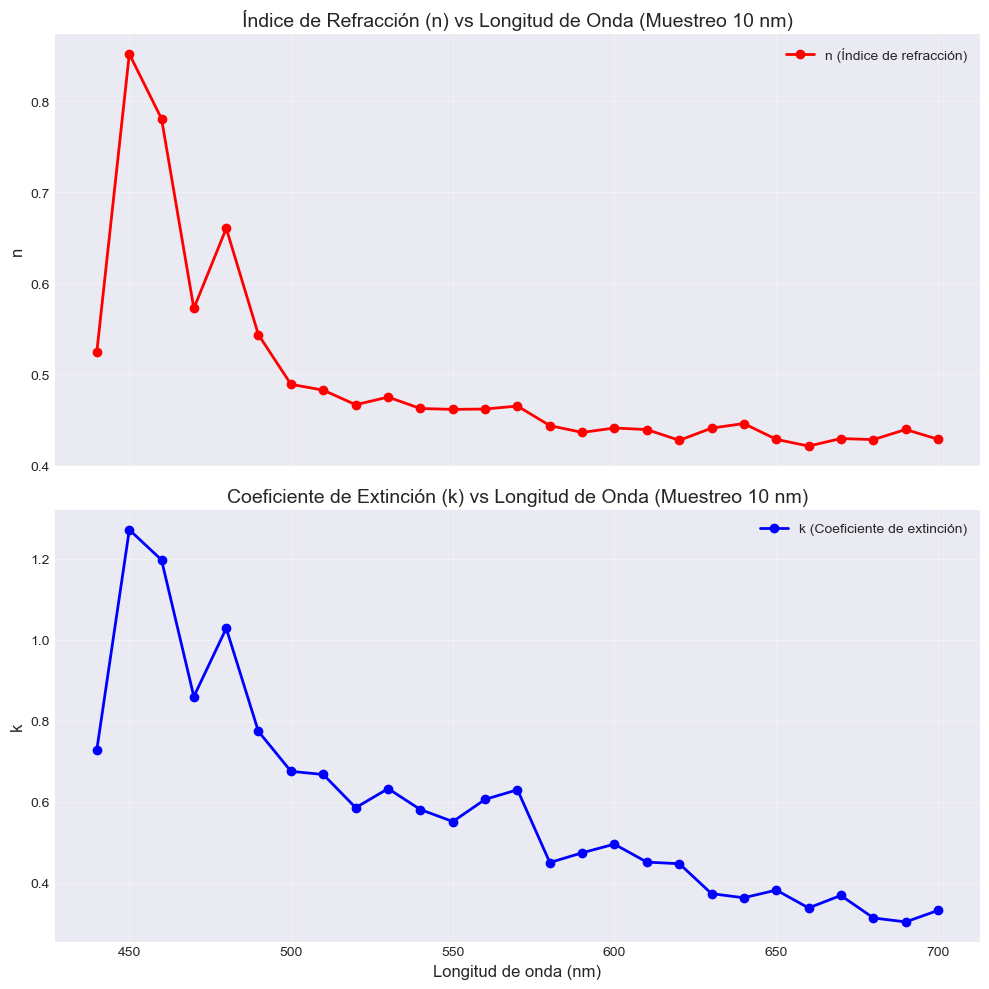


Datos muestreados (440-700 nm, paso ~10 nm):
 Wavelength (nm)        n        k
      440.013489 0.524766 0.729042
      450.049744 0.852125 1.271044
      460.005646 0.780880 1.196593
      469.993561 0.572408 0.859655
      480.012024 0.660421 1.028012
      489.943909 0.543555 0.773852
      500.018799 0.488912 0.675314
      510.003632 0.482544 0.667541
      520.012634 0.466515 0.585633
      530.044495 0.474933 0.632709
      539.980652 0.462379 0.581200
      550.053589 0.461413 0.551448
      560.027649 0.461788 0.606212
      570.018494 0.465077 0.629872
      580.024780 0.443531 0.450444
      590.045166 0.436066 0.474485
      599.960144 0.440945 0.495766
      610.004456 0.439210 0.451480
      620.058777 0.427396 0.447472
      630.003296 0.440788 0.373652
      639.955017 0.445830 0.363563
      650.031067 0.428474 0.382430
      659.993164 0.421066 0.338425
      669.958374 0.429336 0.369268
      680.044190 0.428198 0.313708
      690.011902 0.439290 0.304038
      699

In [17]:
# --- Visualización de Resultados (Muestreo cada 10 nm) ---

# Definir longitudes de onda objetivo: 440 a 700 nm con paso de 10 nm
target_wavelengths = np.arange(440, 701, 10)

# Encontrar los índices más cercanos en los resultados
indices_subset = []
for target in target_wavelengths:
    # Calcular la diferencia absoluta con las longitudes de onda disponibles
    idx = (np.abs(nk_results['Wavelength (nm)'] - target)).argmin()
    indices_subset.append(idx)

# Crear un subconjunto de datos único y ordenado
nk_subset = nk_results.iloc[indices_subset].drop_duplicates().sort_values('Wavelength (nm)')

# Crear la gráfica
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Gráfica de n
ax1.plot(nk_subset['Wavelength (nm)'], nk_subset['n'], 'ro-', linewidth=2, markersize=6, label='n (Índice de refracción)')
ax1.set_ylabel('n', fontsize=12)
ax1.set_title('Índice de Refracción (n) vs Longitud de Onda (Muestreo 10 nm)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfica de k
ax2.plot(nk_subset['Wavelength (nm)'], nk_subset['k'], 'bo-', linewidth=2, markersize=6, label='k (Coeficiente de extinción)')
ax2.set_xlabel('Longitud de onda (nm)', fontsize=12)
ax2.set_ylabel('k', fontsize=12)
ax2.set_title('Coeficiente de Extinción (k) vs Longitud de Onda (Muestreo 10 nm)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Mostrar tabla de datos muestreados
print("\nDatos muestreados (440-700 nm, paso ~10 nm):")
print(nk_subset[['Wavelength (nm)', 'n', 'k']].to_string(index=False))